# Modelagem Econométrica: Brent sob Choque Geopolítico

Este notebook transforma a narrativa exploratória em um exercício de **econometria aplicada**, buscando explicar o `brent_log_return` com fatores macroeconômicos e geopolíticos. O objetivo não é apenas prever, mas principalmente **interpretar elasticidades e sinais econômicos**.

## Estratégia empírica
- Variável dependente: `brent_log_return`.
- Modelos principais: OLS interpretável, Ridge e Lasso para robustez.
- Divisão temporal: treino e teste, preservando a ordem cronológica.
- Diagnósticos: erro fora da amostra, resíduos, autocorrelação aproximada e simulação de cenários.

## Hipótese substantiva
O retorno do Brent deve responder a uma combinação de:
1. condições financeiras globais;
2. fundamentos de oferta;
3. risco geopolítico agregado;
4. choque específico associado ao Estreito de Ormuz.

In [15]:
from pathlib import Path 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso # Modelos de regressão linear, Ridge e Lasso para análise de regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Métricas de avaliação de modelos de regressão
from sklearn.pipeline import Pipeline # Pipeline para encadear etapas de pré-processamento e modelagem
from sklearn.preprocessing import StandardScaler # StandardScaler para normalização dos dados

# Configurações de estilo para visualizações e opções de exibição do pandas para facilitar a análise exploratória dos dados
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_PATH = Path('../data/processed/fuel_dataset_prepared.csv')

In [ ]:
# Função para calcular métricas de regressão, incluindo R², RMSE e MAE, para avaliar o desempenho dos modelos de regressão
def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': rmse,
        'MAE': mean_absolute_error(y_true, y_pred),
    }


# Função para realizar inferência de regressão linear ordinária (OLS), calculando coeficientes, erros padrão, estatísticas t, valores p e intervalos de confiança para cada variável, e retornando um resumo em formato de DataFrame
def ols_inference(X, y, feature_names):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    X_design = np.column_stack([np.ones(len(X)), X])
    xtx_inv = np.linalg.pinv(X_design.T @ X_design)
    beta = xtx_inv @ (X_design.T @ y)
    y_hat = X_design @ beta
    resid = y - y_hat
    n, k = X_design.shape
    sigma2 = (resid @ resid) / (n - k)
    cov = sigma2 * xtx_inv
    se = np.sqrt(np.diag(cov))
    t_stats = beta / se
    p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))
    ci_low = beta - stats.t.ppf(0.975, df=n - k) * se
    ci_high = beta + stats.t.ppf(0.975, df=n - k) * se

    summary = pd.DataFrame({
        'variable': ['const'] + list(feature_names),
        'coef': beta,
        'std_err': se,
        't_stat': t_stats,
        'p_value': p_vals,
        'ci_2.5%': ci_low,
        'ci_97.5%': ci_high,
    })
    return summary, resid, y_hat

# Função para calcular a estatística de Durbin-Watson, que é usada para detectar a presença de autocorrelação nos resíduos de um modelo de regressão, indicando se os resíduos estão correlacionados ao longo do tempo
def durbin_watson(residuals):
    residuals = np.asarray(residuals) # Garantir que os resíduos sejam um array NumPy para cálculos eficientes
    return np.sum(np.diff(residuals) ** 2) / np.sum(residuals ** 2) # Cálculo da estatística de Durbin-Watson para detectar autocorrelação nos resíduos, onde um valor próximo de 2 indica ausência de autocorrelação, valores menores que 2 indicam autocorrelação positiva e valores maiores que 2 indicam autocorrelação negativa

In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
model_df = df.dropna(subset=['brent_log_return']).copy()
model_df['target_pct'] = model_df['brent_log_return'] * 100

base_features = [
    'usd_index_std',
    'interest_rate_std',
    'oil_production_std',
    'oil_stock_std',
    'geopolitical_risk_std',
    'geo_risk_ma3_std',
    'ormuz_dummy',
]

lag_features = [
    'usd_index_lag1', 'usd_index_lag2',
    'interest_rate_lag1', 'interest_rate_lag2',
    'geopolitical_risk_lag1', 'geopolitical_risk_lag2',
    'ormuz_dummy_lag1'
]

model_df[['Date', 'brent_log_return'] + base_features + lag_features].head()

,Date,brent_log_return,usd_index_std,interest_rate_std,oil_production_std,oil_stock_std,geopolitical_risk_std,geo_risk_ma3_std,ormuz_dummy,usd_index_lag1,usd_index_lag2,interest_rate_lag1,interest_rate_lag2,geopolitical_risk_lag1,geopolitical_risk_lag2,ormuz_dummy_lag1
1,2007-08-31,-0.0696,-0.9953,1.9326,0.6578,1.7604,-0.5742,-0.5859,0,80.7786,NaN,5.2600,NaN,-0.5742,NaN,0.0000
2,2007-09-30,0.0792,-1.1578,1.8887,0.1279,-0.6427,-0.5742,-0.5859,0,80.9348,80.7786,5.0200,5.2600,-0.5742,-0.5742,0.0000
3,2007-10-31,0.0667,-1.3026,1.7900,-0.9532,-0.1386,-0.5742,-0.5859,0,79.3021,80.9348,4.9400,5.0200,-0.5742,-0.5742,0.0000
4,2007-11-30,0.1102,-1.5194,1.6420,-1.8027,-1.3389,-0.5742,-0.5859,0,77.8478,79.3021,4.7600,4.9400,-0.5742,-0.5742,0.0000
5,2007-12-31,-0.0073,-1.4104,1.5049,0.7929,1.1246,-0.5742,-0.5859,0,75.6690,77.8478,4.4900,4.7600,-0.5742,-0.5742,0.0000


## Desenho econométrico
Começamos com uma especificação **parsimoniosa e interpretável**. Como a base tem 224 observações úteis após remover o primeiro retorno ausente, o risco principal não é falta de dados, mas sim **sobreajuste** e **multicolinearidade** entre variáveis contemporâneas e defasadas.

Por isso, vamos comparar três arquiteturas:
- **OLS contemporâneo**: sinal econômico e leitura causal mais transparente.
- **OLS com lags**: captura transmissão temporal.
- **Ridge/Lasso**: robustez quando as covariáveis disputam a mesma informação.

In [5]:
correlations = model_df[base_features + lag_features + ['brent_log_return']].corr()['brent_log_return'].sort_values(ascending=False)
correlations.to_frame('corr_with_target')

,corr_with_target
brent_log_return,1.0000
ormuz_dummy_lag1,0.2285
ormuz_dummy,0.1971
geopolitical_risk_lag1,0.1069
geopolitical_risk_std,0.1031
geo_risk_ma3_std,0.0972
oil_production_std,0.0770
geopolitical_risk_lag2,0.0708
usd_index_lag2,-0.0107
interest_rate_std,-0.0111


In [6]:
train_size = int(len(model_df) * 0.7)
train_df = model_df.iloc[:train_size].copy()
test_df = model_df.iloc[train_size:].copy()

print(f'Treino: {train_df.Date.min().date()} até {train_df.Date.max().date()} ({len(train_df)} observações)')
print(f'Teste:  {test_df.Date.min().date()} até {test_df.Date.max().date()} ({len(test_df)} observações)')

Treino: 2007-08-31 até 2020-07-31 (156 observações)
Teste:  2020-08-31 até 2026-03-31 (68 observações)


In [7]:
X_train_base = train_df[base_features]
X_test_base = test_df[base_features]
X_train_lag = train_df[base_features + lag_features].dropna()
X_test_lag = test_df[base_features + lag_features].dropna()

y_train_base = train_df.loc[X_train_base.index, 'brent_log_return']
y_test_base = test_df.loc[X_test_base.index, 'brent_log_return']
y_train_lag = train_df.loc[X_train_lag.index, 'brent_log_return']
y_test_lag = test_df.loc[X_test_lag.index, 'brent_log_return']

ols_base = LinearRegression().fit(X_train_base, y_train_base)
ols_lag = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
]).fit(X_train_lag, y_train_lag)
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
]).fit(X_train_lag, y_train_lag)
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.001, max_iter=10000))
]).fit(X_train_lag, y_train_lag)

predictions = {
    'OLS_base_train': ols_base.predict(X_train_base),
    'OLS_base_test': ols_base.predict(X_test_base),
    'OLS_lag_train': ols_lag.predict(X_train_lag),
    'OLS_lag_test': ols_lag.predict(X_test_lag),
    'Ridge_test': ridge.predict(X_test_lag),
    'Lasso_test': lasso.predict(X_test_lag),
}

metrics = pd.DataFrame([
    {'modelo': 'OLS contemporâneo', 'amostra': 'treino', **regression_metrics(y_train_base, predictions['OLS_base_train'])},
    {'modelo': 'OLS contemporâneo', 'amostra': 'teste', **regression_metrics(y_test_base, predictions['OLS_base_test'])},
    {'modelo': 'OLS com lags', 'amostra': 'treino', **regression_metrics(y_train_lag, predictions['OLS_lag_train'])},
    {'modelo': 'OLS com lags', 'amostra': 'teste', **regression_metrics(y_test_lag, predictions['OLS_lag_test'])},
    {'modelo': 'Ridge', 'amostra': 'teste', **regression_metrics(y_test_lag, predictions['Ridge_test'])},
    {'modelo': 'Lasso', 'amostra': 'teste', **regression_metrics(y_test_lag, predictions['Lasso_test'])},
])
metrics.sort_values(['amostra', 'RMSE'])

,modelo,amostra,R2,RMSE,MAE
1,OLS contemporâneo,teste,-0.2576,0.0845,0.0653
5,Lasso,teste,-0.8614,0.1029,0.0822
4,Ridge,teste,-1.0064,0.1068,0.0857
3,OLS com lags,teste,-1.2474,0.1130,0.0907
2,OLS com lags,treino,0.3694,0.0782,0.0583
0,OLS contemporâneo,treino,0.0280,0.0969,0.0692


In [8]:
ols_summary, ols_resid, ols_fitted = ols_inference(X_train_base, y_train_base, base_features)
ols_summary.sort_values('p_value')

/var/folders/8f/7km_1wvd4x36y2bzhfg90m500000gn/T/ipykernel_28815/3285032821.py:22: RuntimeWarning: invalid value encountered in divide
  t_stats = beta / se


,variable,coef,std_err,t_stat,p_value,ci_2.5%,ci_97.5%
1,usd_index_std,-0.0131,0.0098,-1.3458,0.1804,-0.0324,0.0062
2,interest_rate_std,0.0118,0.0137,0.8643,0.3888,-0.0152,0.0388
4,oil_stock_std,-0.0066,0.0080,-0.8245,0.4110,-0.0225,0.0092
0,const,-0.0055,0.0101,-0.5486,0.5841,-0.0254,0.0143
3,oil_production_std,0.0044,0.0081,0.5415,0.5890,-0.0116,0.0204
6,geo_risk_ma3_std,-0.0124,0.0337,-0.3692,0.7125,-0.0790,0.0541
5,geopolitical_risk_std,0.0055,0.0319,0.1718,0.8638,-0.0575,0.0685
7,ormuz_dummy,0.0000,0.0000,NaN,NaN,0.0000,0.0000


## Leitura dos coeficientes
Como boa parte das variáveis do modelo-base já está padronizada, seus coeficientes podem ser lidos como o efeito aproximado de **1 desvio-padrão** da covariável sobre o log-retorno do Brent.

Isso ajuda a comparar importância relativa. Exemplo de leitura:
- coeficiente positivo em `geopolitical_risk_std`: aumento do risco geopolítico eleva o retorno esperado do Brent;
- coeficiente negativo em `usd_index_std`: fortalecimento do dólar tende a pressionar commodities denominadas em USD;
- coeficiente positivo em `ormuz_dummy`: bloqueio/tensão severa em chokepoint energético aumenta prêmio de risco.

In [9]:
coef_table = pd.DataFrame({
    'feature': base_features,
    'coef_ols_base': ols_base.coef_,
}).sort_values('coef_ols_base', key=lambda s: s.abs(), ascending=False)
coef_table

,feature,coef_ols_base
0,usd_index_std,-0.0131
5,geo_risk_ma3_std,-0.0124
1,interest_rate_std,0.0118
3,oil_stock_std,-0.0066
4,geopolitical_risk_std,0.0055
2,oil_production_std,0.0044
6,ormuz_dummy,0.0000


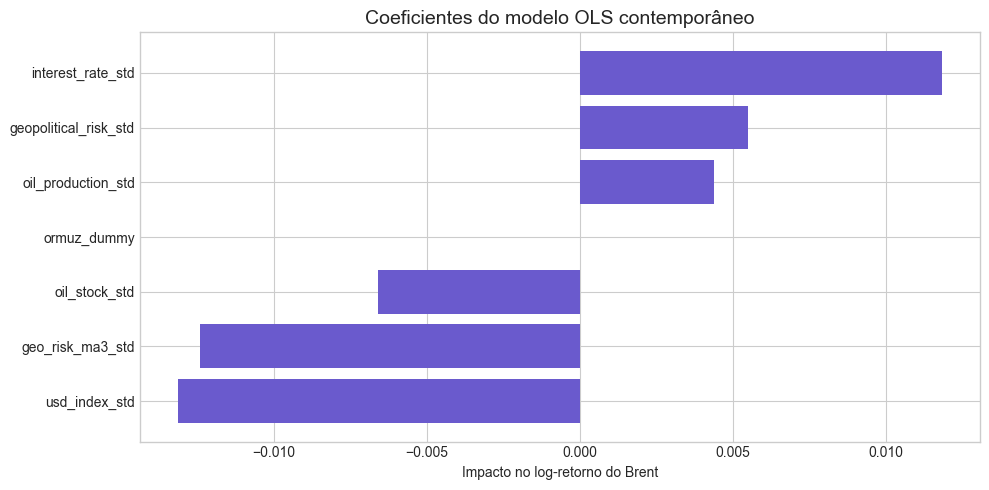

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
coef_table_sorted = coef_table.sort_values('coef_ols_base')
ax.barh(coef_table_sorted['feature'], coef_table_sorted['coef_ols_base'], color='slateblue')
ax.set_title('Coeficientes do modelo OLS contemporâneo')
ax.set_xlabel('Impacto no log-retorno do Brent')
plt.tight_layout()
plt.show()

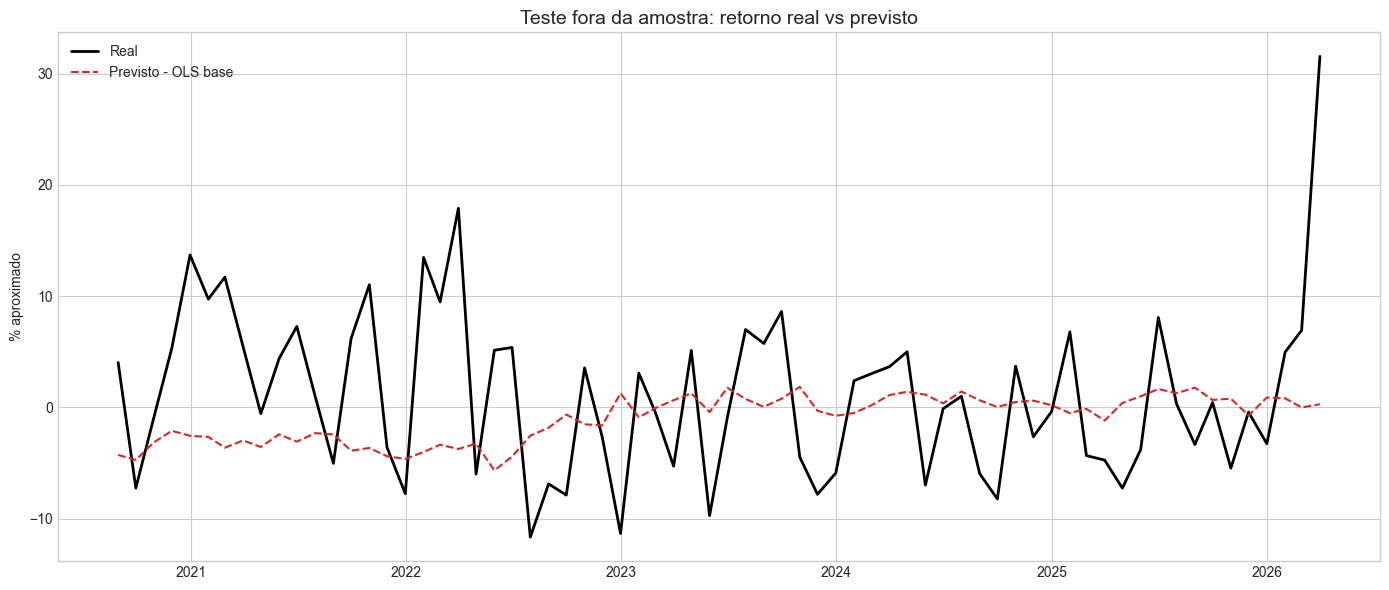

In [11]:
forecast_df = test_df.loc[X_test_base.index, ['Date', 'brent_log_return']].copy()
forecast_df['pred_ols_base'] = predictions['OLS_base_test']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(forecast_df['Date'], forecast_df['brent_log_return'] * 100, label='Real', color='black', linewidth=2)
ax.plot(forecast_df['Date'], forecast_df['pred_ols_base'] * 100, label='Previsto - OLS base', color='tab:red', linestyle='--')
ax.set_title('Teste fora da amostra: retorno real vs previsto')
ax.set_ylabel('% aproximado')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
residual_diagnostics = pd.DataFrame({
    'metric': ['Durbin-Watson', 'Jarque-Bera stat', 'Jarque-Bera p-value', 'Correlação |resíduo| vs ajustado'],
    'value': [
        durbin_watson(ols_resid),
        stats.jarque_bera(ols_resid).statistic,
        stats.jarque_bera(ols_resid).pvalue,
        np.corrcoef(np.abs(ols_resid), ols_fitted)[0, 1],
    ]
})
residual_diagnostics

,metric,value
0,Durbin-Watson,1.1814
1,Jarque-Bera stat,126.5309
2,Jarque-Bera p-value,0.0000
3,Correlação |resíduo| vs ajustado,-0.2493


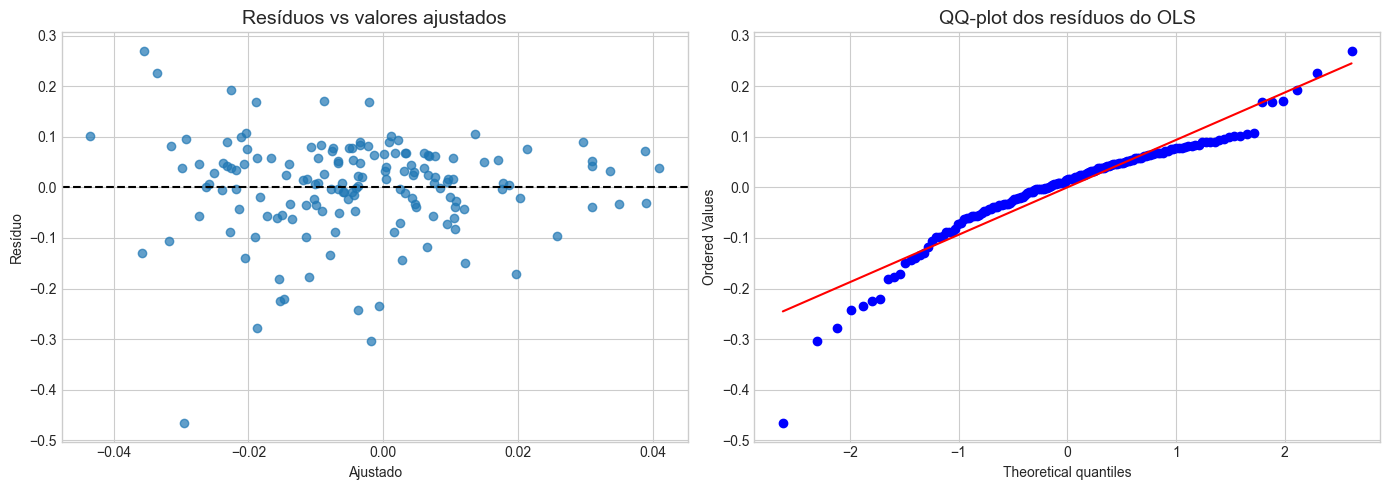

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(ols_fitted, ols_resid, alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Resíduos vs valores ajustados')
axes[0].set_xlabel('Ajustado')
axes[0].set_ylabel('Resíduo')

stats.probplot(ols_resid, dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot dos resíduos do OLS')

plt.tight_layout()
plt.show()

## Simulação de cenários geopolíticos
Um econometrista geopolítico não para em ajuste estatístico: ele traduz o modelo em cenários. Aqui, usamos a última observação disponível como ponto de partida e alteramos apenas o bloco geopolítico.

Os cenários abaixo não são previsão determinística da realidade; são exercícios condicionais do tipo *ceteris paribus*.

In [14]:
latest = model_df.iloc[-1].copy()
geo_q25 = model_df['geopolitical_risk_std'].quantile(0.25)
geo_q75 = model_df['geopolitical_risk_std'].quantile(0.75)
geo_max = model_df['geopolitical_risk_std'].max()
ma_q25 = model_df['geo_risk_ma3_std'].quantile(0.25)
ma_q75 = model_df['geo_risk_ma3_std'].quantile(0.75)
ma_max = model_df['geo_risk_ma3_std'].max()

scenario_rows = []
for scenario, updates in {
    'Normalização geopolítica': {
        'geopolitical_risk_std': geo_q25,
        'geo_risk_ma3_std': ma_q25,
        'ormuz_dummy': 0,
    },
    'Tensão regional elevada': {
        'geopolitical_risk_std': geo_q75,
        'geo_risk_ma3_std': ma_q75,
        'ormuz_dummy': 0,
    },
    'Bloqueio severo de Ormuz': {
        'geopolitical_risk_std': geo_max,
        'geo_risk_ma3_std': ma_max,
        'ormuz_dummy': 1,
    },
}.items():
    row = latest[base_features].copy()
    for key, value in updates.items():
        row[key] = value
    pred = ols_base.predict(pd.DataFrame([row]))[0]
    scenario_rows.append({
        'cenario': scenario,
        'retorno_previsto_log': pred,
        'retorno_previsto_pct_aprox': pred * 100,
    })

scenario_df = pd.DataFrame(scenario_rows).sort_values('retorno_previsto_pct_aprox')
scenario_df

,cenario,retorno_previsto_log,retorno_previsto_pct_aprox
2,Bloqueio severo de Ormuz,-0.0174,-1.7422
1,Tensão regional elevada,-0.0009,-0.0884
0,Normalização geopolítica,0.0057,0.5732


## Conclusão econométrica
A utilidade deste notebook não está apenas no menor erro preditivo. O ganho central é transformar a hipótese substantiva do projeto em uma estrutura mensurável:
- o petróleo responde a canais financeiros globais;
- o componente geopolítico pode carregar prêmio de risco adicional;
- um chokepoint como Ormuz pode ser tratado como choque de cenário, e não apenas como ruído narrativo.

Quando o projeto migrar de variáveis simuladas para séries observadas de produção, estoques e risco geopolítico externo validado, esta arquitetura já estará pronta para uma versão mais robusta, inclusive com extensões para VAR, ARDL, modelos com quebra estrutural ou cenários bayesianos.